### Retail Coffee shop

We have collected a dataset which contains sales of one week in a coffee retail shop. The week sales has been described by hour. 

In order to do the analysis of this dataset, it will be used the Time-Series method and let's see what we are the insights we can possibly find out in this data. 

The problem: To determine the exaclty number of staff for a day shift, focusing on reducing cost which means keep the labour-cost below 31% and keep high performance in store in order to deliver a great quality service for customers. 



In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from datetime import datetime


import warnings
warnings.filterwarnings('ignore') # We can suppress the warnings



In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(rc={'figure.figsize':(10, 4)})
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['figure.dpi'] = 150

In [4]:
data = pd.read_excel('Drumcondra hourly sale week ending 6th.xlsx')

In [5]:
data.head()

,Unnamed: 0,0615,0630,0645,0700,0715,0730,0745,0800,0815,...,1800,1815,1830,1845,1900,1915,1930,1945,2000,Grand Total
0,"OC158 Abbey Street, 30/09/2024",NaN,NaN,NaN,7.929516,47.048459,3.920705,40.088106,30.070378,64.190933,...,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1536.837345
1,"OC158 Abbey Street, 01/10/2024",NaN,NaN,NaN,23.215860,19.162996,17.136564,47.533040,42.466961,48.013178,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1363.574609
2,"OC158 Abbey Street, 02/10/2024",NaN,NaN,4.273128,18.898680,31.530926,21.277533,38.193832,50.572688,53.524230,...,-3.330669e-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1590.105937
3,"OC158 Abbey Street, 03/10/2024",NaN,NaN,NaN,44.411197,26.651983,29.162998,34.449339,33.744493,78.945599,...,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1445.205866
4,"OC158 Abbey Street, 04/10/2024",NaN,NaN,NaN,30.044055,17.491851,18.402202,34.933921,53.392071,36.828195,...,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1321.526463


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 58 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   117 non-null    object 
 1   0615         10 non-null     float64
 2   0630         12 non-null     float64
 3   0645         15 non-null     float64
 4   0700         36 non-null     float64
 5   0715         36 non-null     float64
 6   0730         65 non-null     float64
 7   0745         73 non-null     float64
 8   0800         98 non-null     float64
 9   0815         98 non-null     float64
 10  0830         106 non-null    float64
 11  0845         109 non-null    float64
 12  0900         112 non-null    float64
 13  0915         114 non-null    float64
 14  0930         116 non-null    float64
 15  0945         116 non-null    float64
 16  1000         117 non-null    float64
 17  1015         117 non-null    float64
 18  1030         116 non-null    float64
 19  1045    

In [7]:
df_melted = pd.melt(data, id_vars=['Unnamed: 0'], var_name='Time', value_name='Sales')

print(df_melted)

                              Unnamed: 0         Time          Sales
0         OC158 Abbey Street, 30/09/2024         0615            NaN
1         OC158 Abbey Street, 01/10/2024         0615            NaN
2         OC158 Abbey Street, 02/10/2024         0615            NaN
3         OC158 Abbey Street, 03/10/2024         0615            NaN
4         OC158 Abbey Street, 04/10/2024         0615            NaN
...                                  ...          ...            ...
6664  OC254 Connolly Station, 03/10/2024  Grand Total    1893.085933
6665  OC254 Connolly Station, 04/10/2024  Grand Total    1949.016947
6666  OC254 Connolly Station, 05/10/2024  Grand Total    1567.726733
6667  OC254 Connolly Station, 06/10/2024  Grand Total    1215.311291
6668                         Grand Total  Grand Total  157224.718009

[6669 rows x 3 columns]


In [8]:
df_melted.head(10)

,Unnamed: 0,Time,Sales
0,"OC158 Abbey Street, 30/09/2024",0615,NaN
1,"OC158 Abbey Street, 01/10/2024",0615,NaN
2,"OC158 Abbey Street, 02/10/2024",0615,NaN
3,"OC158 Abbey Street, 03/10/2024",0615,NaN
4,"OC158 Abbey Street, 04/10/2024",0615,NaN
5,"OC158 Abbey Street, 05/10/2024",0615,NaN
6,"OC158 Abbey Street, 06/10/2024",0615,NaN
7,"OC175 Leixlip, 30/09/2024",0615,NaN
8,"OC175 Leixlip, 01/10/2024",0615,NaN
9,"OC175 Leixlip, 02/10/2024",0615,NaN


In [9]:
df_melted['Unnamed: 0'].unique()

array(['OC158 Abbey Street, 30/09/2024', 'OC158 Abbey Street, 01/10/2024',
       'OC158 Abbey Street, 02/10/2024', 'OC158 Abbey Street, 03/10/2024',
       'OC158 Abbey Street, 04/10/2024', 'OC158 Abbey Street, 05/10/2024',
       'OC158 Abbey Street, 06/10/2024', 'OC175 Leixlip, 30/09/2024',
       'OC175 Leixlip, 01/10/2024', 'OC175 Leixlip, 02/10/2024',
       'OC175 Leixlip, 03/10/2024', 'OC175 Leixlip, 04/10/2024',
       'OC175 Leixlip, 05/10/2024', 'OC175 Leixlip, 06/10/2024',
       'OC186 Carpenterstown, 30/09/2024',
       'OC186 Carpenterstown, 01/10/2024',
       'OC186 Carpenterstown, 02/10/2024',
       'OC186 Carpenterstown, 03/10/2024',
       'OC186 Carpenterstown, 04/10/2024',
       'OC186 Carpenterstown, 05/10/2024',
       'OC186 Carpenterstown, 06/10/2024', 'OC190 Ashbourne, 30/09/2024',
       'OC190 Ashbourne, 01/10/2024', 'OC190 Ashbourne, 02/10/2024',
       'OC190 Ashbourne, 03/10/2024', 'OC190 Ashbourne, 04/10/2024',
       'OC190 Ashbourne, 05/10/2024', 'O

In [10]:
df_melted.rename(columns = ({'Unnamed: 0': 'Stores'}), inplace=True)

print(df_melted)

                                  Stores         Time          Sales
0         OC158 Abbey Street, 30/09/2024         0615            NaN
1         OC158 Abbey Street, 01/10/2024         0615            NaN
2         OC158 Abbey Street, 02/10/2024         0615            NaN
3         OC158 Abbey Street, 03/10/2024         0615            NaN
4         OC158 Abbey Street, 04/10/2024         0615            NaN
...                                  ...          ...            ...
6664  OC254 Connolly Station, 03/10/2024  Grand Total    1893.085933
6665  OC254 Connolly Station, 04/10/2024  Grand Total    1949.016947
6666  OC254 Connolly Station, 05/10/2024  Grand Total    1567.726733
6667  OC254 Connolly Station, 06/10/2024  Grand Total    1215.311291
6668                         Grand Total  Grand Total  157224.718009

[6669 rows x 3 columns]


In [11]:
df_melted.columns = df_melted.columns.str.strip()  # Remove leading/trailing spaces
df_melted.columns = df_melted.columns.astype(str)  # Ensure all columns are strings

In [12]:
store_name = 'OC217 Drumcondra'
df_store= df_melted[df_melted['Stores'].str.contains(store_name, na=False)]

print(df_store)

                            Stores         Time        Sales
56    OC217 Drumcondra, 30/09/2024         0615          NaN
57    OC217 Drumcondra, 01/10/2024         0615          NaN
58    OC217 Drumcondra, 02/10/2024         0615          NaN
59    OC217 Drumcondra, 03/10/2024         0615          NaN
60    OC217 Drumcondra, 04/10/2024         0615          NaN
...                            ...          ...          ...
6610  OC217 Drumcondra, 02/10/2024  Grand Total  2082.042054
6611  OC217 Drumcondra, 03/10/2024  Grand Total  2067.444000
6612  OC217 Drumcondra, 04/10/2024  Grand Total  2299.894353
6613  OC217 Drumcondra, 05/10/2024  Grand Total  2397.571909
6614  OC217 Drumcondra, 06/10/2024  Grand Total  2046.513854

[399 rows x 3 columns]


In [13]:
# Extract the date from 'Stores' column
df_store['Date'] = df_store['Stores'].str.extract(r'(\d{2}/\d{2}/\d{4})')
df_store['Date'] = pd.to_datetime(df_store['Date'], format='%d/%m/%Y')

print(df_store)

                            Stores         Time        Sales       Date
56    OC217 Drumcondra, 30/09/2024         0615          NaN 2024-09-30
57    OC217 Drumcondra, 01/10/2024         0615          NaN 2024-10-01
58    OC217 Drumcondra, 02/10/2024         0615          NaN 2024-10-02
59    OC217 Drumcondra, 03/10/2024         0615          NaN 2024-10-03
60    OC217 Drumcondra, 04/10/2024         0615          NaN 2024-10-04
...                            ...          ...          ...        ...
6610  OC217 Drumcondra, 02/10/2024  Grand Total  2082.042054 2024-10-02
6611  OC217 Drumcondra, 03/10/2024  Grand Total  2067.444000 2024-10-03
6612  OC217 Drumcondra, 04/10/2024  Grand Total  2299.894353 2024-10-04
6613  OC217 Drumcondra, 05/10/2024  Grand Total  2397.571909 2024-10-05
6614  OC217 Drumcondra, 06/10/2024  Grand Total  2046.513854 2024-10-06

[399 rows x 4 columns]


In [14]:
df_store.info()

<class 'pandas.core.frame.DataFrame'>
Index: 399 entries, 56 to 6614
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Stores  399 non-null    object        
 1   Time    399 non-null    object        
 2   Sales   315 non-null    float64       
 3   Date    399 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 15.6+ KB


In [15]:
print(df_store.columns)

Index(['Stores', 'Time', 'Sales', 'Date'], dtype='object')


In [16]:
df_store.head()

,Stores,Time,Sales,Date
56,"OC217 Drumcondra, 30/09/2024",0615,NaN,2024-09-30
57,"OC217 Drumcondra, 01/10/2024",0615,NaN,2024-10-01
58,"OC217 Drumcondra, 02/10/2024",0615,NaN,2024-10-02
59,"OC217 Drumcondra, 03/10/2024",0615,NaN,2024-10-03
60,"OC217 Drumcondra, 04/10/2024",0615,NaN,2024-10-04


In [17]:
df_store.tail(10)

,Stores,Time,Sales,Date
6495,"OC217 Drumcondra, 04/10/2024",2000,NaN,2024-10-04
6496,"OC217 Drumcondra, 05/10/2024",2000,NaN,2024-10-05
6497,"OC217 Drumcondra, 06/10/2024",2000,NaN,2024-10-06
6608,"OC217 Drumcondra, 30/09/2024",Grand Total,2042.757577,2024-09-30
6609,"OC217 Drumcondra, 01/10/2024",Grand Total,1931.940308,2024-10-01
6610,"OC217 Drumcondra, 02/10/2024",Grand Total,2082.042054,2024-10-02
6611,"OC217 Drumcondra, 03/10/2024",Grand Total,2067.444000,2024-10-03
6612,"OC217 Drumcondra, 04/10/2024",Grand Total,2299.894353,2024-10-04
6613,"OC217 Drumcondra, 05/10/2024",Grand Total,2397.571909,2024-10-05
6614,"OC217 Drumcondra, 06/10/2024",Grand Total,2046.513854,2024-10-06


### Dropping rows with the sales grand total that will not be used in the analysis

In [19]:
indices_to_drop = [6608, 6609,6610, 6611, 6612, 6613, 6614]

df_store = df_store.drop(indices_to_drop)

In [20]:
df_store

,Stores,Time,Sales,Date
56,"OC217 Drumcondra, 30/09/2024",0615,NaN,2024-09-30
57,"OC217 Drumcondra, 01/10/2024",0615,NaN,2024-10-01
58,"OC217 Drumcondra, 02/10/2024",0615,NaN,2024-10-02
59,"OC217 Drumcondra, 03/10/2024",0615,NaN,2024-10-03
60,"OC217 Drumcondra, 04/10/2024",0615,NaN,2024-10-04
...,...,...,...,...
6493,"OC217 Drumcondra, 02/10/2024",2000,NaN,2024-10-02
6494,"OC217 Drumcondra, 03/10/2024",2000,NaN,2024-10-03
6495,"OC217 Drumcondra, 04/10/2024",2000,NaN,2024-10-04
6496,"OC217 Drumcondra, 05/10/2024",2000,NaN,2024-10-05


In [21]:
# Convert Time column to string if needed
df_store['Time'] = df_store['Time'].astype(str)

# Combine Date and Time
df_store['Datetime'] = pd.to_datetime(df_store['Date'].astype(str) + ' ' + df_store['Time'])

# Set datetime as index
df_store = df_store.set_index('Datetime')

# Sort index (important for time series)
df_store = df_store.sort_index()

print(df_store.head())

                                           Stores  Time  Sales       Date
Datetime                                                                 
2024-09-30 06:15:00  OC217 Drumcondra, 30/09/2024  0615    NaN 2024-09-30
2024-09-30 06:30:00  OC217 Drumcondra, 30/09/2024  0630    NaN 2024-09-30
2024-09-30 06:45:00  OC217 Drumcondra, 30/09/2024  0645    NaN 2024-09-30
2024-09-30 07:00:00  OC217 Drumcondra, 30/09/2024  0700    NaN 2024-09-30
2024-09-30 07:15:00  OC217 Drumcondra, 30/09/2024  0715    NaN 2024-09-30


In [22]:
new = df_store[['Time', 'Sales', 'Date']]

new.head()


,Time,Sales,Date
Datetime,,,
2024-09-30 06:15:00,0615,NaN,2024-09-30
2024-09-30 06:30:00,0630,NaN,2024-09-30
2024-09-30 06:45:00,0645,NaN,2024-09-30
2024-09-30 07:00:00,0700,NaN,2024-09-30
2024-09-30 07:15:00,0715,NaN,2024-09-30


In [23]:
new.dtypes

Time             object
Sales           float64
Date     datetime64[ns]
dtype: object

In [24]:
dfnew = new[['Sales']]

dfnew.head()

,Sales
Datetime,
2024-09-30 06:15:00,NaN
2024-09-30 06:30:00,NaN
2024-09-30 06:45:00,NaN
2024-09-30 07:00:00,NaN
2024-09-30 07:15:00,NaN


### Verifying 'Datetime' feature has set up as DatetimeIndex.

In [26]:
dfnew.index

DatetimeIndex(['2024-09-30 06:15:00', '2024-09-30 06:30:00',
               '2024-09-30 06:45:00', '2024-09-30 07:00:00',
               '2024-09-30 07:15:00', '2024-09-30 07:30:00',
               '2024-09-30 07:45:00', '2024-09-30 08:00:00',
               '2024-09-30 08:15:00', '2024-09-30 08:30:00',
               ...
               '2024-10-06 17:45:00', '2024-10-06 18:00:00',
               '2024-10-06 18:15:00', '2024-10-06 18:30:00',
               '2024-10-06 18:45:00', '2024-10-06 19:00:00',
               '2024-10-06 19:15:00', '2024-10-06 19:30:00',
               '2024-10-06 19:45:00', '2024-10-06 20:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=392, freq=None)

In [27]:
business_hour = dfnew[(dfnew.index.time >= pd.to_datetime("07:30").time()) & 
        (dfnew.index.time <= pd.to_datetime("18:30").time())]

business_hour

,Sales
Datetime,
2024-09-30 07:30:00,31.321587
2024-09-30 07:45:00,34.933921
2024-09-30 08:00:00,12.643172
2024-09-30 08:15:00,46.960354
2024-09-30 08:30:00,28.267614
...,...
2024-10-06 17:30:00,36.519824
2024-10-06 17:45:00,10.396476
2024-10-06 18:00:00,8.370044


In [28]:
drop_na_strategy = business_hour.dropna()
drop_na_strategy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 305 entries, 2024-09-30 07:30:00 to 2024-10-06 18:30:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   305 non-null    float64
dtypes: float64(1)
memory usage: 4.8 KB


In [29]:
drop_na_strategy.sort_values(by=['Datetime'],inplace=True)

drop_na_strategy.head()

,Sales
Datetime,
2024-09-30 07:30:00,31.321587
2024-09-30 07:45:00,34.933921
2024-09-30 08:00:00,12.643172
2024-09-30 08:15:00,46.960354
2024-09-30 08:30:00,28.267614


In [30]:
drop_na_strategy.tail()

,Sales
Datetime,
2024-10-06 17:30:00,36.519824
2024-10-06 17:45:00,10.396476
2024-10-06 18:00:00,8.370044
2024-10-06 18:15:00,36.809497
2024-10-06 18:30:00,0.000000


### Plot Timeseries

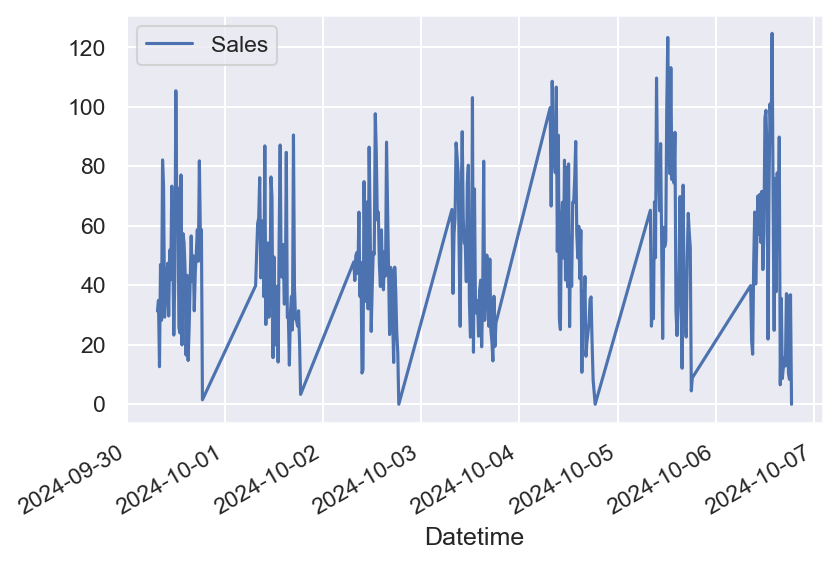

In [32]:
drop_na_strategy.plot();

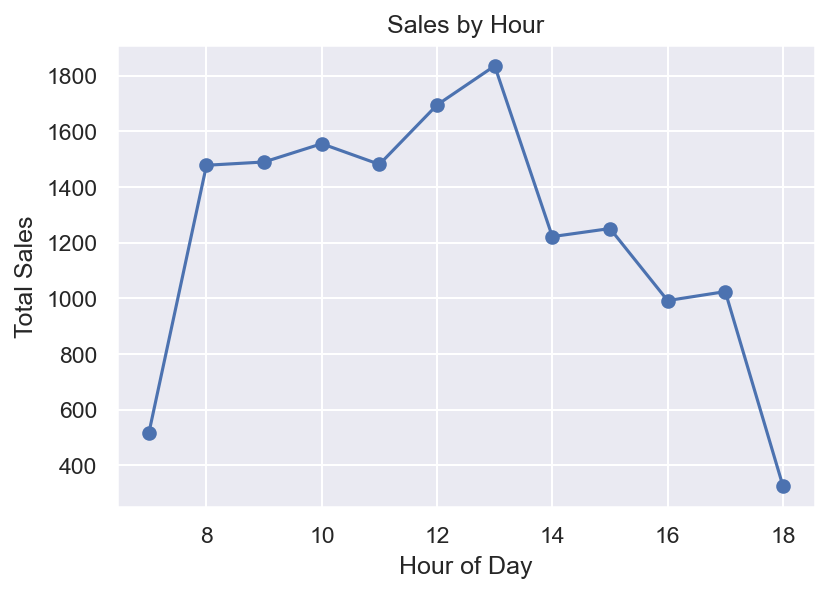

In [33]:
#Visualizing by hour 
sales_hourly = drop_na_strategy.groupby(drop_na_strategy.index.hour)['Sales'].sum()

sales_hourly.plot(marker='o')
plt.xlabel("Hour of Day")
plt.ylabel("Total Sales")
plt.title("Sales by Hour")
plt.show()

### Sales 30th September 24 from 7:30 am to 18:30 pm

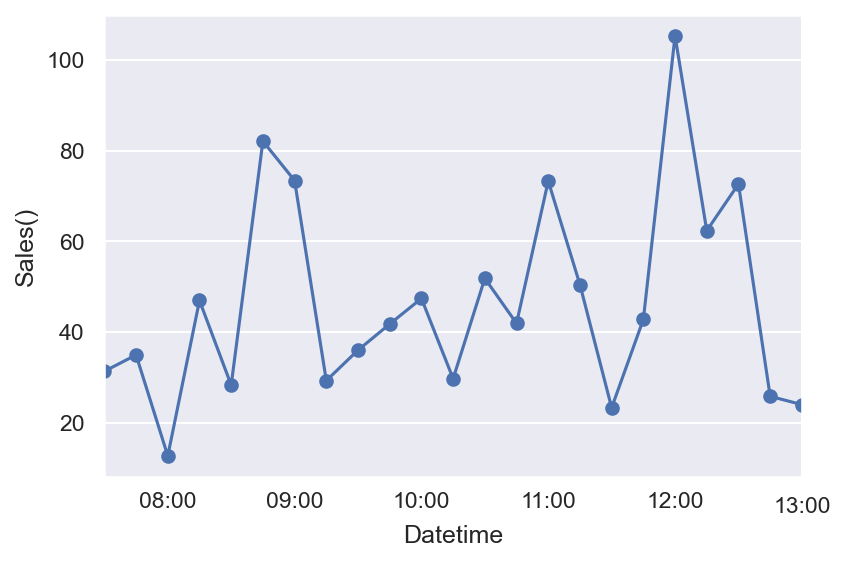

In [35]:
ax = drop_na_strategy.loc['2024-09-30 07:30:00':'2024-09-30 13:00:00',
'Sales'].plot(marker='o', linestyle='-')
ax.set_ylabel('Sales()');

### Sales from 11:30 am to 15:00 pm

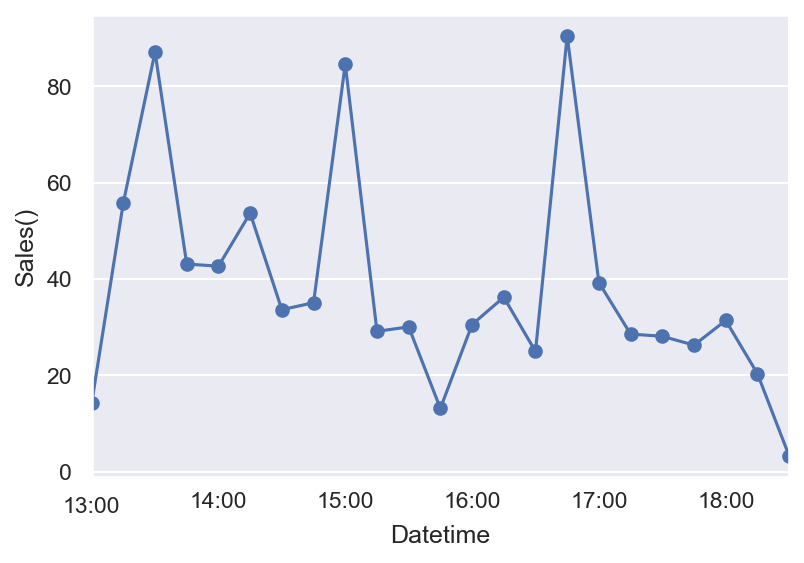

In [37]:
ax = drop_na_strategy.loc['2024-10-01 13:00:00':'2024-10-01 18:30:00',
'Sales'].plot(marker='o', linestyle='-')
ax.set_ylabel('Sales()');

In [38]:
newdata = drop_na_strategy.loc['2024-09-30 07:30:00':'2024-09-30 18:30:00',
'Sales']

newdata

Datetime
2024-09-30 07:30:00     31.321587
2024-09-30 07:45:00     34.933921
2024-09-30 08:00:00     12.643172
2024-09-30 08:15:00     46.960354
2024-09-30 08:30:00     28.267614
2024-09-30 08:45:00     82.140970
2024-09-30 09:00:00     73.436124
2024-09-30 09:15:00     29.260593
2024-09-30 09:30:00     35.991191
2024-09-30 09:45:00     41.757639
2024-09-30 10:00:00     47.412878
2024-09-30 10:15:00     29.691630
2024-09-30 10:30:00     51.841803
2024-09-30 10:45:00     41.903764
2024-09-30 11:00:00     73.331006
2024-09-30 11:15:00     50.452349
2024-09-30 11:30:00     23.269404
2024-09-30 11:45:00     42.777299
2024-09-30 12:00:00    105.390746
2024-09-30 12:15:00     62.370440
2024-09-30 12:30:00     72.676738
2024-09-30 12:45:00     25.790983
2024-09-30 13:00:00     23.964758
2024-09-30 13:15:00     77.093048
2024-09-30 13:30:00     19.955947
2024-09-30 13:45:00     57.389647
2024-09-30 14:00:00     54.493394
2024-09-30 14:15:00     45.671896
2024-09-30 14:30:00     16.519823
2024-

In [39]:
# Creating a dataframe with the predicted values 
newdata = pd.DataFrame(newdata,index = newdata.index,columns=["Sales"])

newdata

,Sales
Datetime,
2024-09-30 07:30:00,31.321587
2024-09-30 07:45:00,34.933921
2024-09-30 08:00:00,12.643172
2024-09-30 08:15:00,46.960354
2024-09-30 08:30:00,28.267614
2024-09-30 08:45:00,82.140970
2024-09-30 09:00:00,73.436124
2024-09-30 09:15:00,29.260593
2024-09-30 09:30:00,35.991191


In [40]:
!pip install pmdarima
from pmdarima.arima import auto_arima

In [41]:
stepwise_model = auto_arima(newdata, start_p=1,start_q=1,start_d= 0, start_P=0, max_p=6, max_q=6, m=1, seasonal=False, trace=True, stepwise=False)

 ARIMA(0,0,0)(0,0,0)[0]             : AIC=481.657, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=459.079, Time=0.03 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=446.444, Time=0.08 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=441.230, Time=0.20 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=440.805, Time=0.10 sec
 ARIMA(0,0,5)(0,0,0)[0]             : AIC=438.808, Time=0.26 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=429.397, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.19 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.18 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.22 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=423.485, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.15 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.21 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=424.307, Ti

In [42]:
train = newdata.loc['2024-09-30 07:30:00':'2024-09-30 14:30:00']
test = newdata.loc['2024-09-30 14:45:00':]

In [43]:
train

,Sales
Datetime,
2024-09-30 07:30:00,31.321587
2024-09-30 07:45:00,34.933921
2024-09-30 08:00:00,12.643172
2024-09-30 08:15:00,46.960354
2024-09-30 08:30:00,28.267614
2024-09-30 08:45:00,82.140970
2024-09-30 09:00:00,73.436124
2024-09-30 09:15:00,29.260593
2024-09-30 09:30:00,35.991191


In [44]:
test

,Sales
Datetime,
2024-09-30 14:45:00,43.346229
2024-09-30 15:00:00,14.713657
2024-09-30 15:15:00,25.665091
2024-09-30 15:30:00,40.806025
2024-09-30 15:45:00,56.607929
2024-09-30 16:00:00,41.286130
2024-09-30 16:15:00,49.896217
2024-09-30 16:30:00,31.409691
2024-09-30 16:45:00,44.362666


In [45]:
stepwise_model.fit(train)

ARIMA(order=(5, 0, 0), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

In [46]:
future_forecast = stepwise_model.predict(n_periods=16)

In [47]:
future_forecast

2024-09-30 14:45:00    30.152240
2024-09-30 15:00:00    40.190705
2024-09-30 15:15:00    39.508560
2024-09-30 15:30:00    35.015167
2024-09-30 15:45:00    27.496372
2024-09-30 16:00:00    30.733801
2024-09-30 16:15:00    33.170308
2024-09-30 16:30:00    32.619662
2024-09-30 16:45:00    30.616440
2024-09-30 17:00:00    28.362513
2024-09-30 17:15:00    28.858647
2024-09-30 17:30:00    29.176406
2024-09-30 17:45:00    28.640511
2024-09-30 18:00:00    27.638182
2024-09-30 18:15:00    26.704507
2024-09-30 18:30:00    26.489058
Freq: 15min, dtype: float64

In [48]:
future_forecast = pd.DataFrame(future_forecast,index = test.index,columns=["Sales"])

<Axes: xlabel='Datetime'>

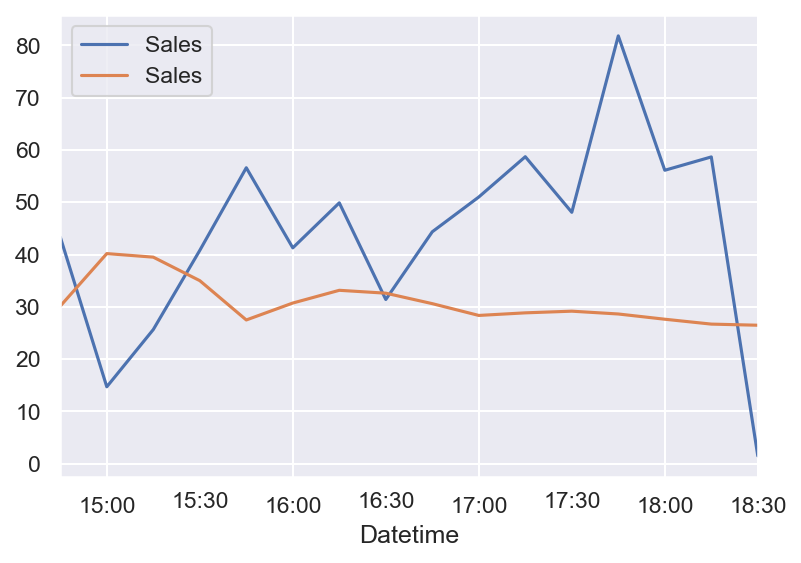

In [49]:
#azul test laranja forecast
pd.concat([test,future_forecast],axis=1).plot()

<Axes: xlabel='Datetime'>

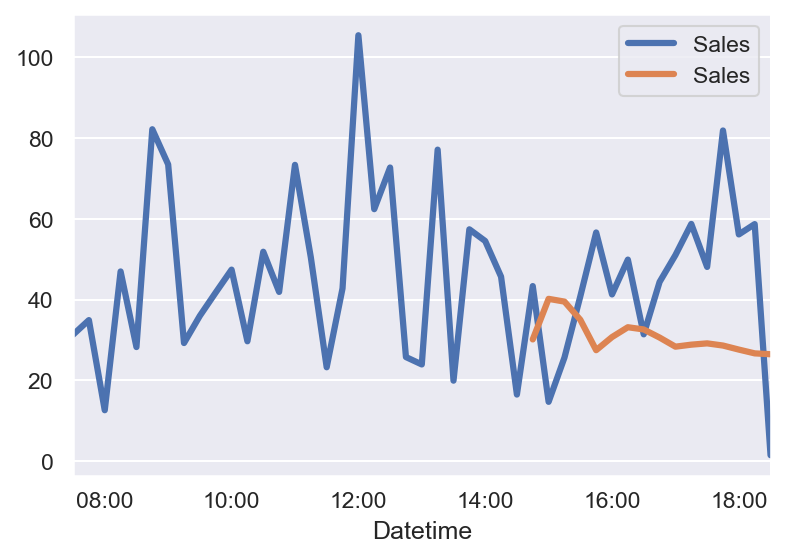

In [50]:
pd.concat([newdata,future_forecast],axis=1).plot(linewidth=3)